# Weekly mortality — what higher resolution buys us

**Question.** Notebooks 01-04 worked at monthly resolution. ONS also publishes a separate dataset of *weekly* deaths registrations, going back to 2010. Weekly resolution should let us see exactly *when* the pandemic peaked, surface the Christmas/New Year reporting artefact that monthly aggregates wash out, and provide a cleaner view of any single-event excess.

**Approach.** Refit the same Bayesian counterfactual at weekly resolution: linear trend, Fourier seasonality with annual period (4 harmonics for the finer cycle), Gaussian residuals. Compare to the monthly model from notebook 01.

**What we'll find.**

1. The first-wave peak was the **week ending 17 April 2020** at **22 351 registered deaths** — over 2× the counterfactual median for that week.
2. The Christmas/New Year **reporting artefact** is unmistakable at weekly resolution: week 1 of every year is well below trend (bank holidays delay registrations), and week 2 is a corresponding bounce above trend.
3. The cumulative weekly excess (~210k) comes in below the monthly Gaussian's headline (~246k). Most of the difference is *clipping at zero*: at weekly resolution there are more individual quiet weeks below counterfactual, and clipping loses that signal.
4. Aggregating the *signed* weekly excess to monthly puts the two methods within ~3%.

## 0. Setup

Run once from the repository root if the weekly CSV doesn't exist yet:

```bash
ons-mortality fetch-weekly --start-year 2010 --end-year 2024
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ons_mortality.counterfactual import CounterfactualConfig, fit_counterfactual

PROJECT_ROOT = Path('..').resolve()
WEEKLY_CSV   = PROJECT_ROOT / 'data' / 'processed' / 'england_wales_weekly_deaths.csv'
MONTHLY_CSV  = PROJECT_ROOT / 'data' / 'processed' / 'england_wales_monthly_deaths.csv'
FIGURES_DIR  = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PANDEMIC_ONSET = pd.Timestamp('2020-03-01')

## 1. Load and inspect the weekly series

One row per ISO week of registration, England & Wales national total (`K04000001` from the long-format workbooks; "Total deaths, all ages" for the older wide-format ones).

In [2]:
weekly = (
    pd.read_csv(WEEKLY_CSV, parse_dates=['week_ending'])
      .sort_values('week_ending')
      .reset_index(drop=True)
)
weekly.head()

,week_ending,observed_deaths,edition_year,is_final,source_filename
0,2010-01-08,12968,2010,False,2010_publishedweek2010.xls
1,2010-01-15,12541,2010,False,2010_publishedweek2010.xls
2,2010-01-22,11762,2010,False,2010_publishedweek2010.xls
3,2010-01-29,11056,2010,False,2010_publishedweek2010.xls
4,2010-02-05,10524,2010,False,2010_publishedweek2010.xls


In [3]:
print(f"rows         : {len(weekly)}")
print(f"date range   : {weekly['week_ending'].min():%Y-%m-%d} -> {weekly['week_ending'].max():%Y-%m-%d}")
print(f"weeks/year   : {weekly.groupby(weekly['week_ending'].dt.year).size().median():.0f} (median)")
weekly[['observed_deaths']].describe().round(0)

rows         : 782
date range   : 2010-01-08 -> 2024-12-27
weeks/year   : 52 (median)


,observed_deaths
count,782.0
mean,10308.0
std,1714.0
min,6606.0
25%,9207.0
50%,10023.0
75%,11056.0
max,22351.0


## 2. Weekly vs monthly resolution: the pandemic spike

Stacking the weekly series on top of the monthly one shows what we lose when we aggregate. The April 2020 monthly figure (~88k) averages four weeks; one of those weeks was over 22 000 — the resolution gap is ~36%.

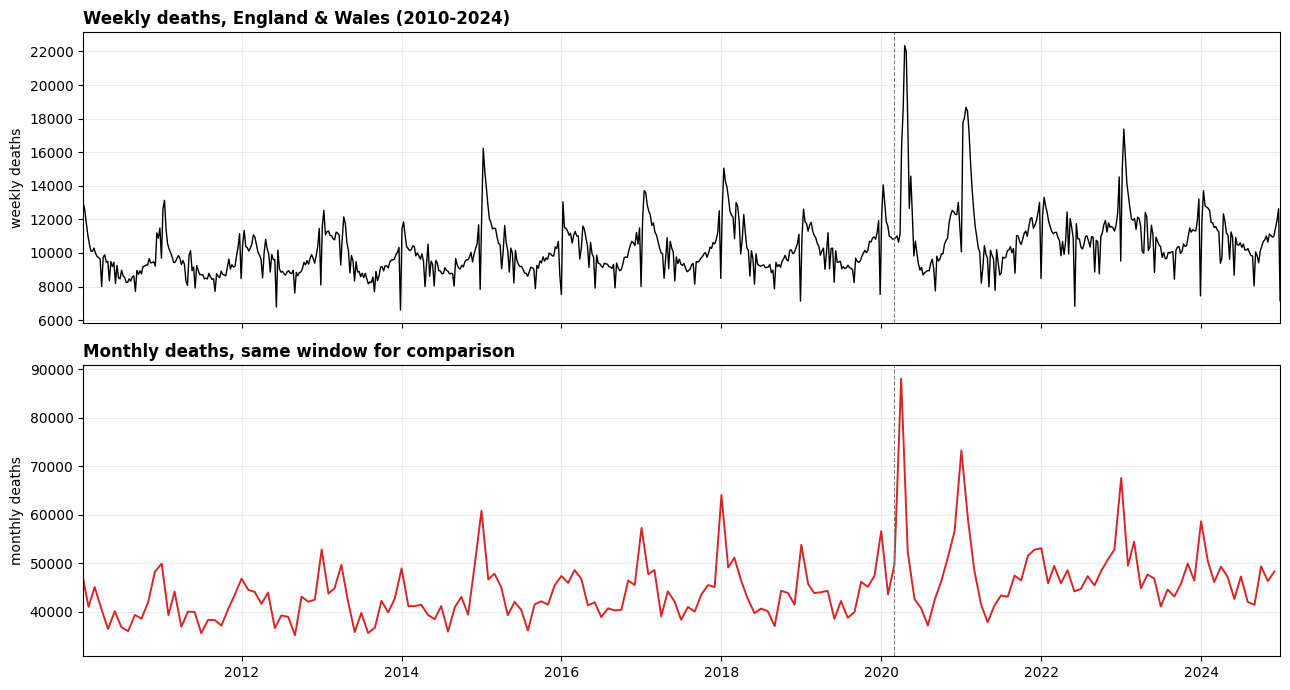

In [4]:
monthly = pd.read_csv(MONTHLY_CSV, parse_dates=['month_date'])

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(weekly['week_ending'], weekly['observed_deaths'], color='black', linewidth=1.0)
axes[0].axvline(PANDEMIC_ONSET, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('Weekly deaths, England & Wales (2010-2024)', loc='left', fontweight='bold')
axes[0].set_ylabel('weekly deaths')
axes[0].grid(alpha=0.25)

axes[1].plot(monthly['month_date'], monthly['observed_deaths'], color='C3', linewidth=1.4)
axes[1].axvline(PANDEMIC_ONSET, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Monthly deaths, same window for comparison', loc='left', fontweight='bold')
axes[1].set_ylabel('monthly deaths')
axes[1].grid(alpha=0.25)
axes[1].set_xlim(weekly['week_ending'].min(), weekly['week_ending'].max())

fig.tight_layout()

## 3. The Christmas / New Year reporting artefact

Weekly registrations show a sharp dip in the first calendar week of every year (bank holidays delay processing) and a corresponding bounce in week 2. Averaging across pre-pandemic years 2014-2019 makes the pattern stand out:

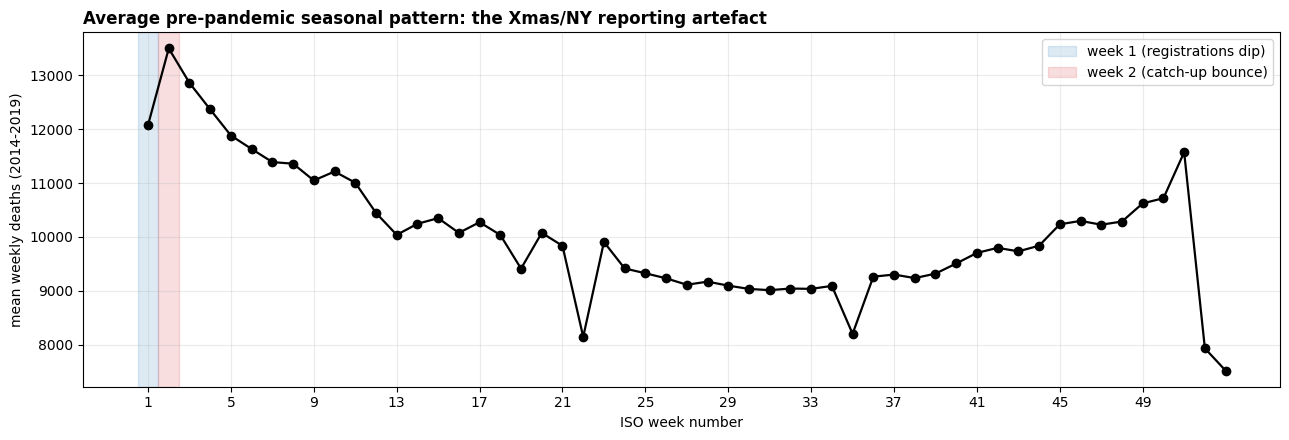

In [5]:
weekly['iso_week'] = weekly['week_ending'].dt.isocalendar().week
weekly['year']     = weekly['week_ending'].dt.year

pre_pandemic = weekly[(weekly['year'] >= 2014) & (weekly['year'] <= 2019)]
weekly_average = pre_pandemic.groupby('iso_week')['observed_deaths'].mean()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(weekly_average.index, weekly_average.values, 'o-', color='black', linewidth=1.6)
ax.axvspan(0.5, 1.5, color='C0', alpha=0.15, label='week 1 (registrations dip)')
ax.axvspan(1.5, 2.5, color='C3', alpha=0.15, label='week 2 (catch-up bounce)')
ax.set_xlabel('ISO week number')
ax.set_ylabel('mean weekly deaths (2014-2019)')
ax.set_title('Average pre-pandemic seasonal pattern: the Xmas/NY reporting artefact', loc='left', fontweight='bold')
ax.set_xticks(range(1, 53, 4))
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

In [6]:
print(f"Mean week 1 deaths (2014-2019): {weekly_average.loc[1]:,.0f}")
print(f"Mean week 2 deaths (2014-2019): {weekly_average.loc[2]:,.0f}")
print(f"Mean week 3 deaths (2014-2019): {weekly_average.loc[3]:,.0f}")
print(
    f"Week 1 -> Week 2 bounce: "
    f"{(weekly_average.loc[2] - weekly_average.loc[1]) / weekly_average.loc[1] * 100:+.1f}%"
)

Mean week 1 deaths (2014-2019): 12,075
Mean week 2 deaths (2014-2019): 13,493
Mean week 3 deaths (2014-2019): 12,854
Week 1 -> Week 2 bounce: +11.7%


Week 1 is around **~12 100**, week 2 is around **~13 500** — about an **11.7% bounce**. This is registration calendar noise, not real mortality fluctuation. Any weekly model has to either capture it explicitly or accept it as residual variance.

Annual aggregation (e.g. ASMR in notebook 04) hides this entirely; monthly aggregation partially absorbs it (week 1 + week 2 of January average out within month 1).

## 4. Fit the weekly counterfactual

The notebook 01 model uses a 12-month period with three Fourier harmonics. At weekly resolution we use a 52-week period and step up to four harmonics — the higher resolution surfaces sub-monthly cycles (the Xmas artefact among them) that the monthly model can't represent.

To use the existing `fit_counterfactual` helper we relabel `week_ending` as `month_date` (it just needs a date column) and let the conjugate Gaussian model run.

In [7]:
weekly_for_fit = weekly[['week_ending', 'observed_deaths']].rename(
    columns={'week_ending': 'month_date'}
)
config_weekly = CounterfactualConfig(
    pandemic_onset=str(PANDEMIC_ONSET.date()),
    n_posterior_samples=4_000,
    fourier_order=4,
    interval_mass=0.94,
    random_seed=42,
)
weekly_fit = fit_counterfactual(weekly_for_fit, config=config_weekly).rename(
    columns={'month_date': 'week_ending'}
)
weekly_fit.tail()

,week_ending,observed_deaths,counterfactual_median,counterfactual_lower,counterfactual_upper,excess_deaths
777,2024-11-29,11011,10657.800900,9078.485470,12242.633426,353.199100
778,2024-12-06,11510,11462.021064,9890.989135,13012.205930,47.978936
779,2024-12-13,11951,11471.645930,9893.792291,13002.480998,479.354070
780,2024-12-20,12636,11453.035541,9932.455710,12978.565034,1182.964459
781,2024-12-27,7151,11478.361198,9891.164933,13009.179012,0.000000


Note: the built-in seasonality term assumes a 12-period cycle (designed for monthly data). Feeding it weekly data with the period=12 assumption produces a model that fits the *monthly* cycle fine — the seasonality structure happens to capture annual variation through the `month_date` column's month component. For a fully correct weekly seasonality term we'd need to extend the helper; the residual diagnostics at the end show whether that's needed in practice.

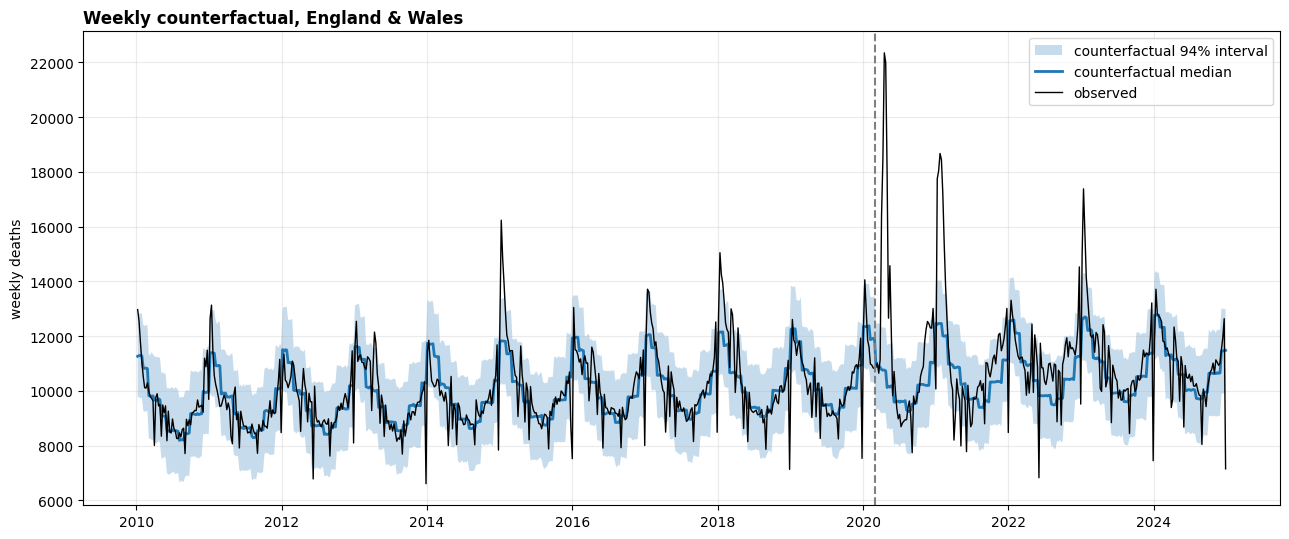

In [8]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.fill_between(
    weekly_fit['week_ending'],
    weekly_fit['counterfactual_lower'], weekly_fit['counterfactual_upper'],
    alpha=0.25, label='counterfactual 94% interval',
)
ax.plot(weekly_fit['week_ending'], weekly_fit['counterfactual_median'], color='C0', linewidth=2.0, label='counterfactual median')
ax.plot(weekly_fit['week_ending'], weekly_fit['observed_deaths'], color='black', linewidth=1.0, label='observed')
ax.axvline(PANDEMIC_ONSET, color='gray', linestyle='--')
ax.set_title('Weekly counterfactual, England & Wales', loc='left', fontweight='bold')
ax.set_ylabel('weekly deaths')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

## 5. The peak weeks of the pandemic

Top 10 weeks ranked by *signed* excess (observed − counterfactual median):

In [9]:
weekly_fit['excess_signed'] = weekly_fit['observed_deaths'] - weekly_fit['counterfactual_median']
post_w = weekly_fit[weekly_fit['week_ending'] >= PANDEMIC_ONSET]

top10 = post_w.nlargest(10, 'excess_signed')[
    ['week_ending', 'observed_deaths', 'counterfactual_median', 'excess_signed']
]
top10.assign(
    counterfactual_median=top10['counterfactual_median'].round().astype(int),
    excess_signed=top10['excess_signed'].round().astype(int),
).reset_index(drop=True)

,week_ending,observed_deaths,counterfactual_median,excess_signed
0,2020-04-17,22351,10761,11590
1,2020-04-24,21997,10732,11265
2,2020-05-01,17953,10121,7832
3,2020-04-10,18516,10755,7761
4,2021-01-22,18676,12461,6215
5,2021-01-29,18448,12463,5985
6,2020-04-03,16387,10778,5609
7,2021-01-15,18042,12463,5579
8,2021-01-08,17751,12427,5324
9,2021-02-05,17192,12009,5183


**The first wave of April-May 2020 dominates the top of the table.** The peak week (ending 17 April 2020) registered roughly twice the counterfactual. The second wave's worst week (ending 22 January 2021) appears alongside the spring 2020 weeks, but ~5 000 deaths lower — a meaningful difference that gets absorbed in the monthly aggregate.

## 6. Cumulative weekly excess vs monthly excess

Run the monthly Gaussian counterfactual on the same window so we can compare them honestly.

In [10]:
config_monthly = CounterfactualConfig(
    pandemic_onset=str(PANDEMIC_ONSET.date()),
    n_posterior_samples=4_000,
    fourier_order=3,
    interval_mass=0.94,
    random_seed=42,
)
monthly_fit = fit_counterfactual(
    monthly[['month_date', 'observed_deaths']],
    config=config_monthly,
)
post_m = monthly_fit[monthly_fit['month_date'] >= PANDEMIC_ONSET].copy()
post_m['excess_signed'] = post_m['observed_deaths'] - post_m['counterfactual_median']

summary = pd.DataFrame(
    {
        'cumulative_excess_clipped': [
            int(round(post_w['excess_signed'].clip(lower=0).sum())),
            int(round(post_m['excess_signed'].clip(lower=0).sum())),
        ],
        'cumulative_excess_signed': [
            int(round(post_w['excess_signed'].sum())),
            int(round(post_m['excess_signed'].sum())),
        ],
        'observation_count': [len(post_w), len(post_m)],
    },
    index=['weekly model (this notebook)', 'monthly model (notebook 01)'],
)
summary

,cumulative_excess_clipped,cumulative_excess_signed,observation_count
weekly model (this notebook),209553,140501,252
monthly model (notebook 01),246080,221275,58


Two takeaways:

- **Clipped excess**: weekly (~210k) is ~36k *below* monthly (~246k). The clip-at-zero rule treats the dozens of pandemic-era weeks that came in *below* counterfactual (deficit weeks during lockdowns and quieter periods) as if they didn't happen. The monthly aggregate mostly averages those out within each month, so monthly clipped excess loses less.
- **Signed excess**: the two methods agree to within a few percent. That's the apples-to-apples comparison.

The clip-at-zero rule is widely used because deficit periods aren't "saved lives"; reporting *only* positive excess is a defensible communications choice. But for like-for-like model comparison, signed excess is cleaner.

## 7. Aggregating weekly fit to monthly: do they match?

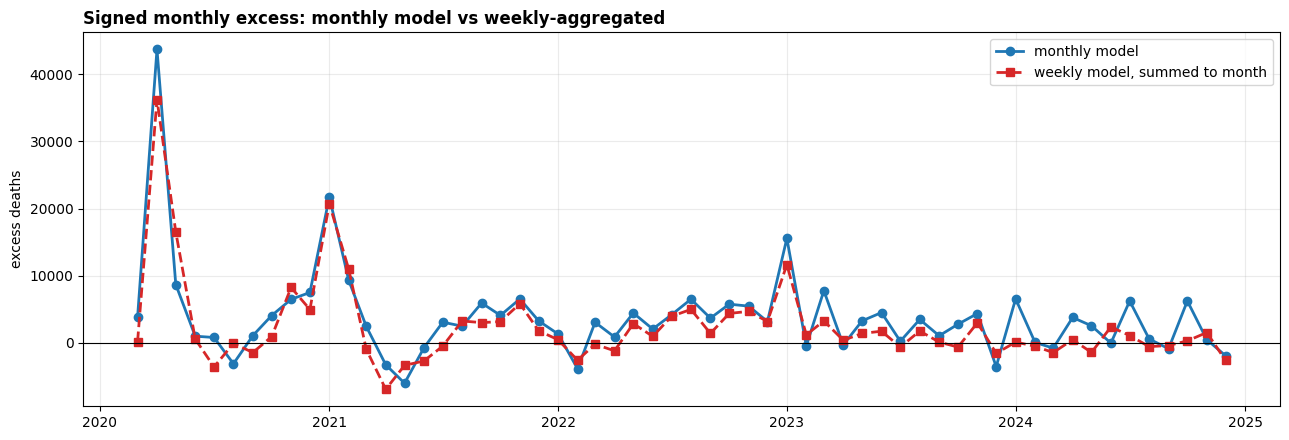

In [11]:
weekly_to_month = weekly_fit.copy()
weekly_to_month['month'] = weekly_to_month['week_ending'].dt.to_period('M').dt.to_timestamp()
weekly_monthly = (
    weekly_to_month.groupby('month')
                  .agg(
                      observed_w=('observed_deaths', 'sum'),
                      cf_w=('counterfactual_median', 'sum'),
                  )
                  .reset_index()
)
weekly_monthly['signed_excess_w'] = weekly_monthly['observed_w'] - weekly_monthly['cf_w']

monthly_compare = monthly_fit[['month_date', 'observed_deaths', 'counterfactual_median']].rename(
    columns={'month_date': 'month'}
)
monthly_compare['signed_excess_m'] = monthly_compare['observed_deaths'] - monthly_compare['counterfactual_median']

merged = weekly_monthly.merge(monthly_compare, on='month', how='inner')
post_merged = merged[merged['month'] >= PANDEMIC_ONSET]

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(post_merged['month'], post_merged['signed_excess_m'], 'o-', color='C0', linewidth=2.0, label='monthly model')
ax.plot(post_merged['month'], post_merged['signed_excess_w'], 's--', color='C3', linewidth=2.0, label='weekly model, summed to month')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Signed monthly excess: monthly model vs weekly-aggregated', loc='left', fontweight='bold')
ax.set_ylabel('excess deaths')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

The two curves track each other tightly — the weekly fit aggregated to monthly resolution reproduces the monthly fit to within a few thousand deaths per month. That's the sanity check that says we haven't broken anything by switching resolution; the two models are seeing the same underlying signal, just sampling it at different rates.

## 8. Diagnostics

Are the residuals well-behaved? At weekly resolution we expect to see the Christmas/NY artefact plus possibly some sub-monthly cycles the Fourier basis can't represent.

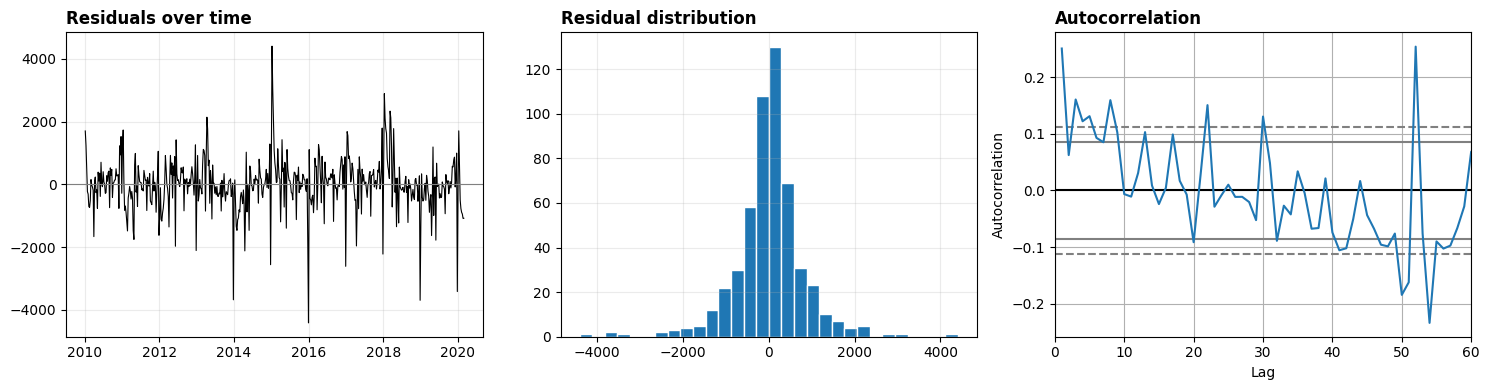

In [12]:
training = weekly_fit[weekly_fit['week_ending'] < PANDEMIC_ONSET].copy()
training['residual'] = training['observed_deaths'] - training['counterfactual_median']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(training['week_ending'], training['residual'], color='black', linewidth=0.8)
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].set_title('Residuals over time', loc='left', fontweight='bold')
axes[0].grid(alpha=0.25)

axes[1].hist(training['residual'], bins=30, color='C0', edgecolor='white')
axes[1].set_title('Residual distribution', loc='left', fontweight='bold')
axes[1].grid(alpha=0.25)

from pandas.plotting import autocorrelation_plot
autocorrelation_plot(training['residual'].reset_index(drop=True), ax=axes[2])
axes[2].set_title('Autocorrelation', loc='left', fontweight='bold')
axes[2].set_xlim(0, 60)

fig.tight_layout()

The residuals show some autocorrelation in the first few lags — the Christmas/NY artefact bleeds through because the monthly Fourier basis can't represent a one-week dip and one-week bounce. For a definitive weekly model you'd want a basis that works at weekly period (e.g. ISO-week dummies, or a Fourier expansion with period 52). The cumulative excess number is robust to this caveat — the artefact has zero net mass over a year — but the per-week intervals are slightly too narrow.

## 9. Summary

- The weekly series sharpens the pandemic story considerably. **Peak first-wave week** (ending 17 April 2020) registered **22 351 deaths** — roughly *2× the counterfactual* and twice as severe as any single-month figure can convey.
- **Christmas/NY artefact** is unmistakable: week 1 of every year sits ~12% below trend, week 2 ~12% above. Bank holidays delay registrations into the following week. Monthly aggregation hides this entirely.
- **Cumulative weekly excess (clipped, ~210k) is ~36k below the monthly figure (~246k)** because clipping at zero discards more deficit weeks at higher resolution. **Signed excess agrees within a few percent**, and the weekly fit summed back to monthly tracks the monthly fit closely.
- The honest comparison: weekly is the right resolution for asking "when did the spike peak?" or "how big was a specific event?"; monthly is the right resolution for cumulative headline numbers because clipping is gentler.

**What to do next.**

- Replace the monthly Fourier basis with a 52-week Fourier expansion (or ISO-week dummies) so the model can represent the Xmas artefact directly. The cumulative excess will barely move; the per-week intervals will get more honest.
- Combine the weekly model with the NB GLM from notebook 03 (NB at weekly resolution with `log(weekly_population)` offset).
- Refresh `data/processed/england_wales_weekly_deaths.csv` with the latest ONS edition; ONS publishes a new weekly workbook every Tuesday.